<div align="center">
<h1><b>Exploratory Data Analysis (EDA)</b></h1>
</div>

In [1]:
# Import Libraries and Load the cleaned Datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

# Load both datasets
urban = pd.read_csv('../data/processed/clean_urban_data.csv', parse_dates=['datetime'])
acn   = pd.read_csv('../data/processed/clean_acn_data.csv',   parse_dates=['connectionTime'])
info  = pd.read_csv('../data/processed/station_metadata.csv')

print("Urban EV:", urban.shape)
print("ACN Data:", acn.shape)
print("Stations:", info.shape)

Urban EV: (2134080, 32)
ACN Data: (15013, 29)
Stations: (247, 10)


In [2]:
# Sanity Check for the Datasets
print("=== URBAN EV ===")
print("Date range:", urban['datetime'].min(), "→", urban['datetime'].max())
print("Stations:  ", urban['station_id'].nunique())
print("Avg occupancy:", round(urban['occupancy'].mean(), 3))
print("Avg utilization:", round(urban['charger_utilization_rate'].mean(), 3))

print("\n=== ACN DATA ===")
print("Date range:", acn['connectionTime'].min(), "→", acn['connectionTime'].max())
print("Stations:  ", acn['stationID'].nunique())
print("Avg kWh:   ", round(acn['kWhDelivered'].mean(), 2))
print("Avg session duration (hrs):", round(acn['session_duration_hrs'].mean(), 2))

=== URBAN EV ===
Date range: 2022-06-19 00:00:00 → 2022-07-18 23:55:00
Stations:   247
Avg occupancy: 21.902
Avg utilization: 0.28

=== ACN DATA ===
Date range: 2018-04-25 11:08:04 → 2018-12-16 23:56:30
Stations:   54
Avg kWh:    9.0
Avg session duration (hrs): 5.92


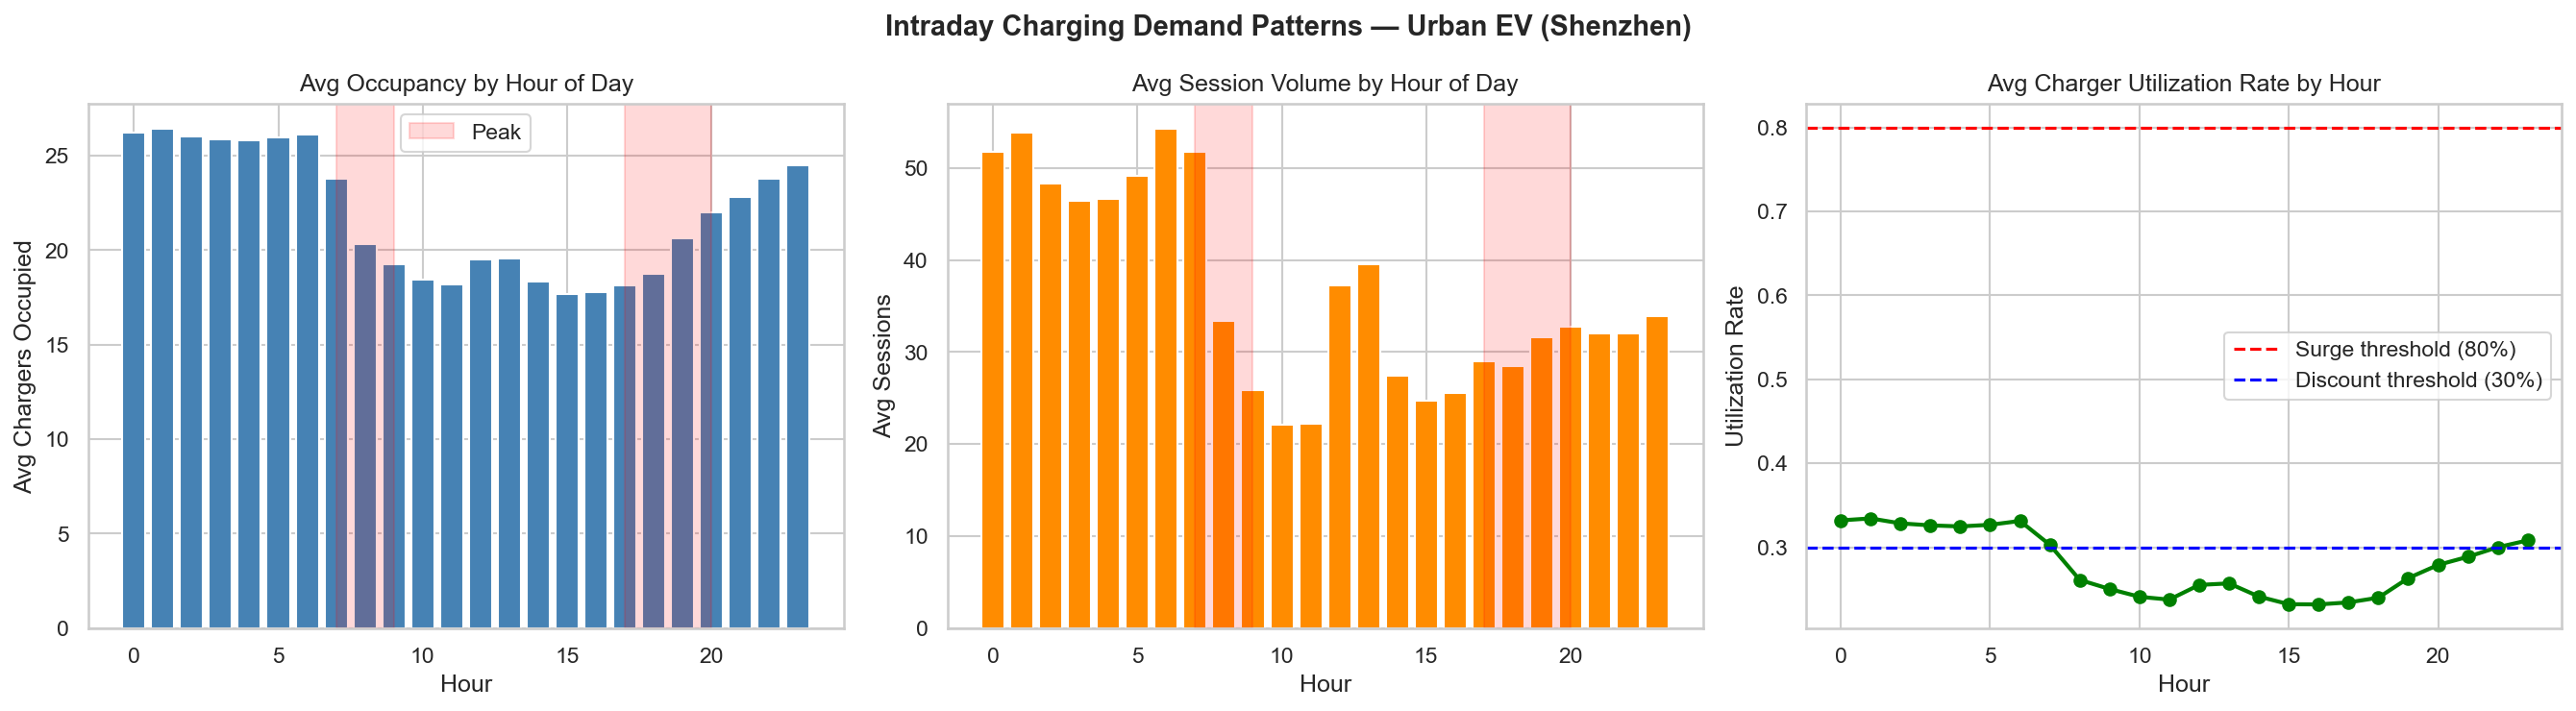

Saved: intraday_demand_pattern.png


In [3]:
# EDA 1: Intraday Demand pattern (Urban EV Dataset)

# Average occupancy and volume by hour across all stations
hourly = urban.groupby('hour').agg(
    avg_occupancy=('occupancy','mean'),
    avg_volume=('volume','mean'),
    avg_utilization=('charger_utilization_rate','mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Occupancy
axes[0].bar(hourly['hour'], hourly['avg_occupancy'], color='steelblue', edgecolor='white')
axes[0].set_title('Avg Occupancy by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Chargers Occupied')
axes[0].axvspan(7, 9, alpha=0.15, color='red', label='Peak')
axes[0].axvspan(17, 20, alpha=0.15, color='red')
axes[0].legend()

# Volume
axes[1].bar(hourly['hour'], hourly['avg_volume'], color='darkorange', edgecolor='white')
axes[1].set_title('Avg Session Volume by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Avg Sessions')
axes[1].axvspan(7, 9, alpha=0.15, color='red')
axes[1].axvspan(17, 20, alpha=0.15, color='red')

# Utilization Rate
axes[2].plot(hourly['hour'], hourly['avg_utilization'], marker='o', color='green', linewidth=2)
axes[2].axhline(0.8, color='red', linestyle='--', label='Surge threshold (80%)')
axes[2].axhline(0.3, color='blue', linestyle='--', label='Discount threshold (30%)')
axes[2].set_title('Avg Charger Utilization Rate by Hour')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Utilization Rate')
axes[2].legend()

plt.suptitle('Intraday Charging Demand Patterns — Urban EV (Shenzhen)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/eda/intraday_demand_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: intraday_demand_pattern.png")

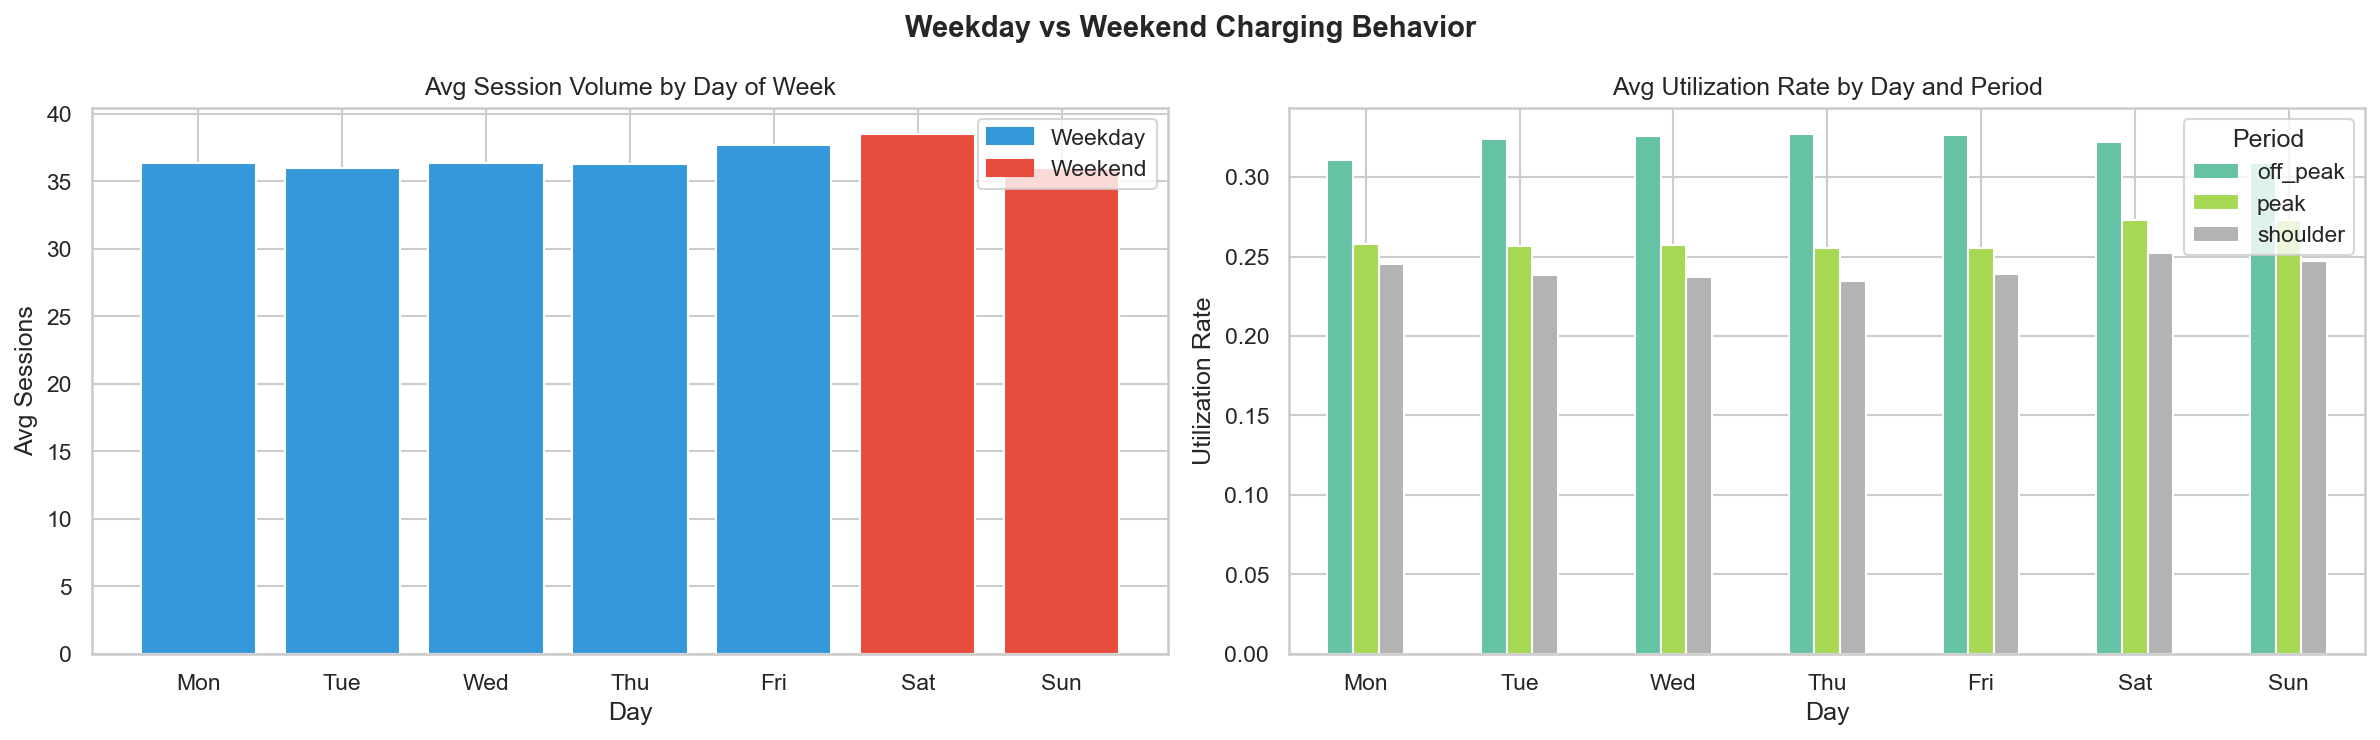

Saved: weekday_vs_weekend.png


In [4]:
# EDA 2:  Weekday vs Weekend Behavior (Urban EV Dataset)

weekly = urban.groupby(['day_of_week','is_weekend','period']).agg(
    avg_volume=('volume','mean'),
    avg_utilization=('charger_utilization_rate','mean')
).reset_index()

day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
weekly['day_name'] = weekly['day_of_week'].map(dict(enumerate(day_labels)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volume by day
# Session Volumes by each day of the week

day_vol = urban.groupby('day_of_week')['volume'].mean().reset_index()
day_vol['day_name'] = day_vol['day_of_week'].map(dict(enumerate(day_labels)))
colors = ['#e74c3c' if d >= 5 else '#3498db' for d in day_vol['day_of_week']]

axes[0].bar(day_vol['day_name'], day_vol['volume'], color=colors, edgecolor='white')
axes[0].set_title('Avg Session Volume by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Avg Sessions')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#3498db', label='Weekday'),
    Patch(color='#e74c3c', label='Weekend')
])

# Utilization by day and period
# Utilization rate for each day and period

pivot_util = weekly.pivot_table(
    values='avg_utilization', index='day_name', columns='period'
)
pivot_util = pivot_util.reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
pivot_util.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Avg Utilization Rate by Day and Period')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Utilization Rate')
axes[1].legend(title='Period')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Weekday vs Weekend Charging Behavior', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/eda/weekday_vs_weekend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: weekday_vs_weekend.png")

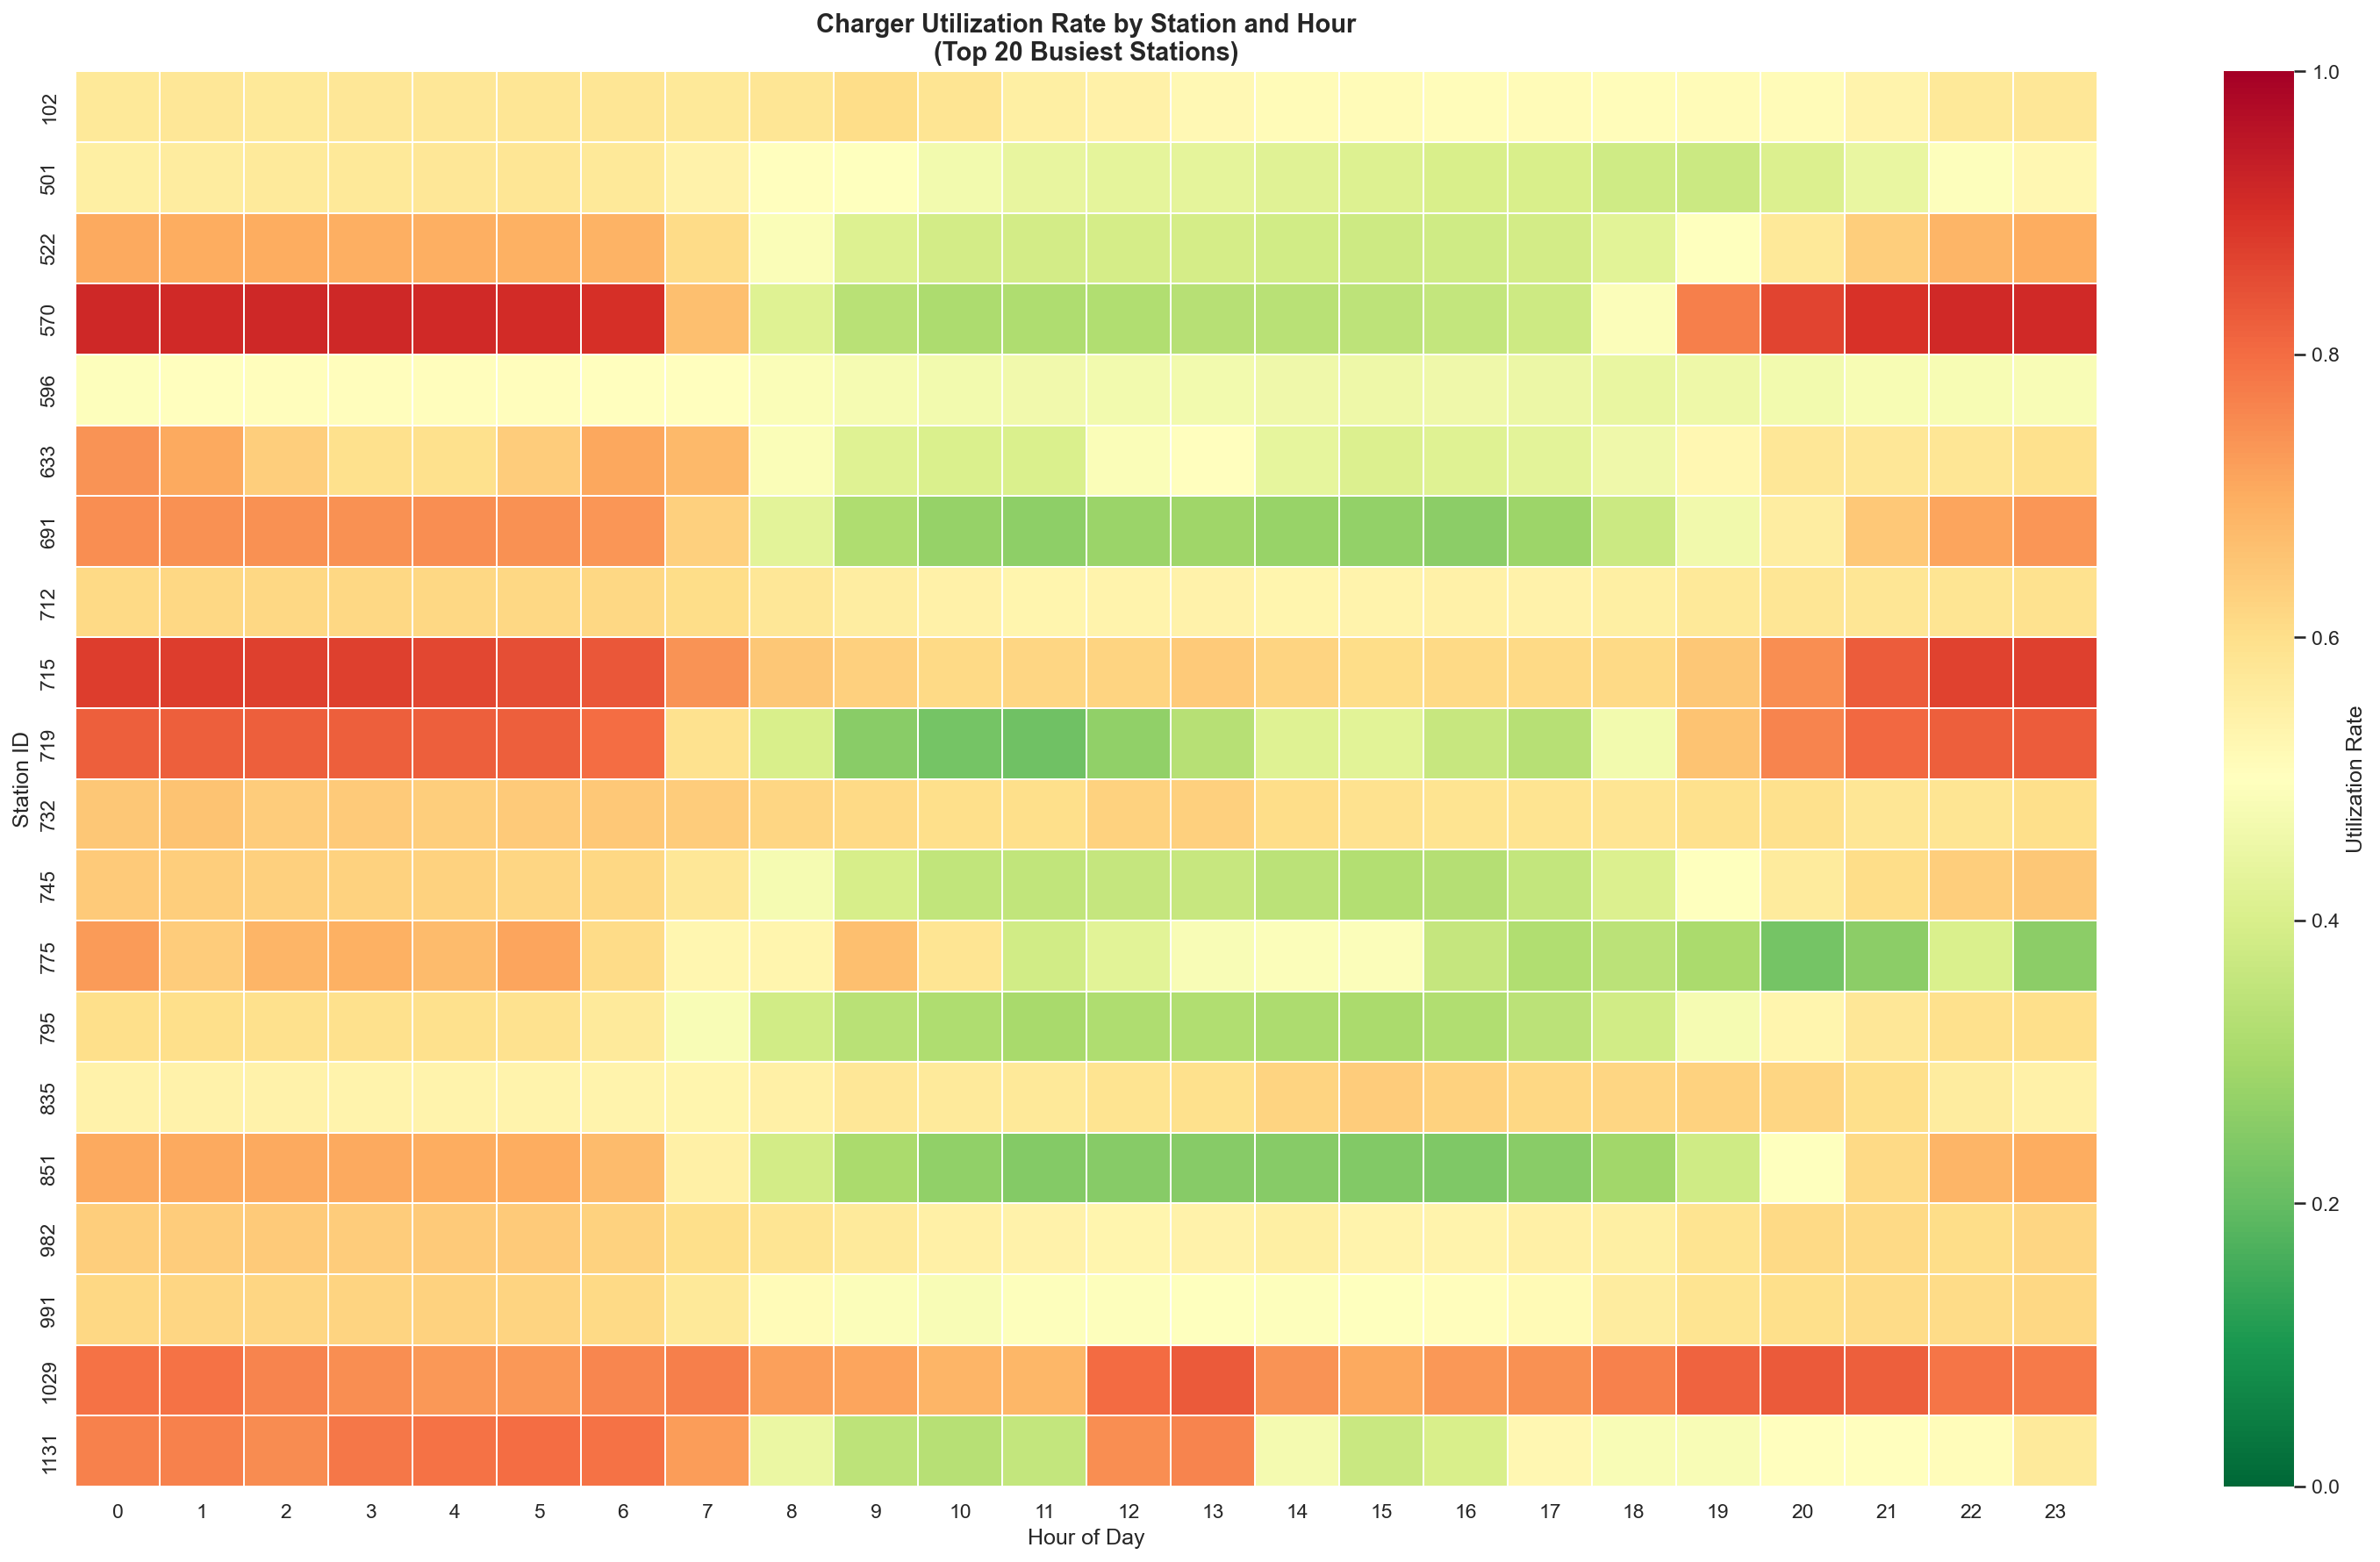

Saved: station_utilization_heatmap.png


In [12]:
# EDA 3: Station Utilisation Heatmap (Urban EV)
# Pivot: stations (rows) × hours (cols) — mean utilization
# Use top 20 stations by avg utilization to keep readable

# Getting the top 20 stations
top_stations = (
    urban.groupby('station_id')['charger_utilization_rate']
    .mean()
    .nlargest(20)
    .index
)

# Generation of heatmap data
heatmap_data = (
    urban[urban['station_id'].isin(top_stations)]
    .groupby(['station_id','hour'])['charger_utilization_rate']
    .mean()
    .unstack(level='hour')
)

# Plotting the heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(
    heatmap_data,
    cmap='RdYlGn_r',
    linewidths=0.2,
    annot=False,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Utilization Rate'}
)
plt.title('Charger Utilization Rate by Station and Hour\n(Top 20 Busiest Stations)',
          fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Station ID')
plt.tight_layout()
plt.savefig('../visuals/eda/station_utilization_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: station_utilization_heatmap.png")

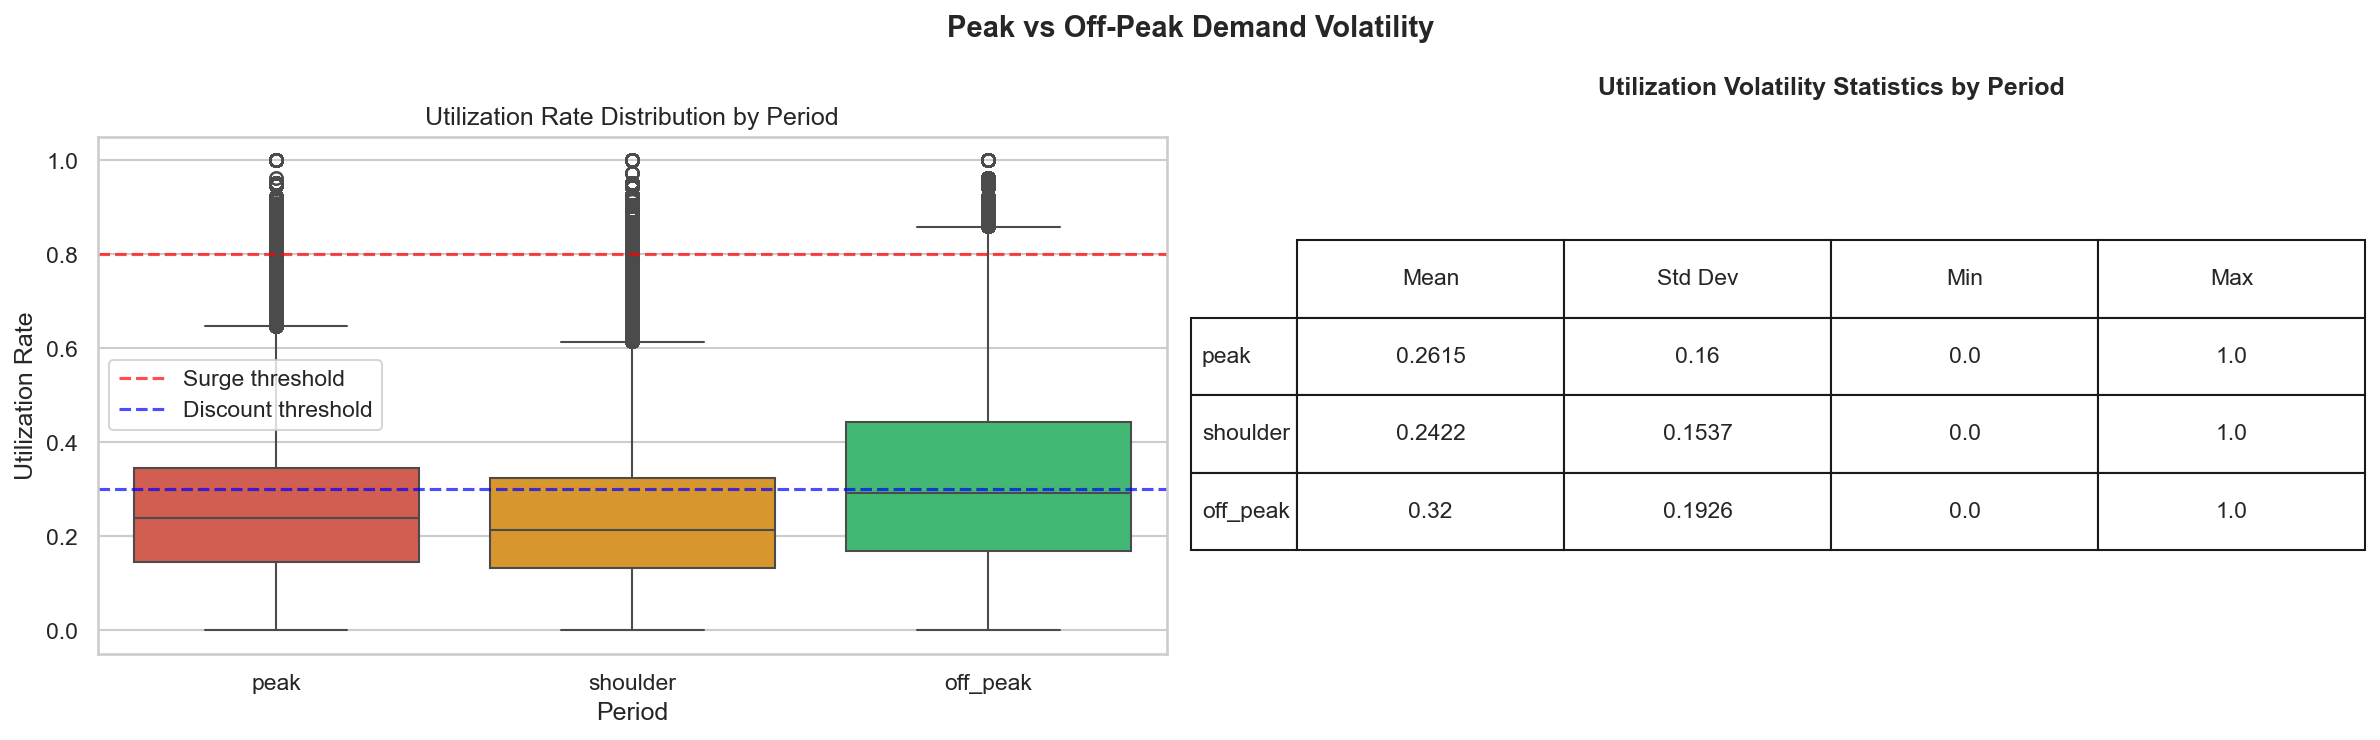

Saved: peak_offpeak_volatility.png


In [6]:
# EDA 4: Peak vs Off-Peak Volatility (Urban EV)
# Boxplots and statistics showing demand spread across peak, shoulder, and off-peak periods

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot — utilization by period
period_order = ['peak','shoulder','off_peak']
period_colors = {'peak':'#e74c3c','shoulder':'#f39c12','off_peak':'#2ecc71'}

sns.boxplot(
    data=urban,
    x='period', y='charger_utilization_rate',
    order=period_order,
    palette=period_colors,
    ax=axes[0]
)
axes[0].axhline(0.8, color='red', linestyle='--', alpha=0.7, label='Surge threshold')
axes[0].axhline(0.3, color='blue', linestyle='--', alpha=0.7, label='Discount threshold')
axes[0].set_title('Utilization Rate Distribution by Period')
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Utilization Rate')
axes[0].legend()

# Volatility table — std dev by period
vol_stats = urban.groupby('period')['charger_utilization_rate'].agg(
    ['mean','std','min','max']
).reindex(period_order).round(4)

axes[1].axis('off')
table = axes[1].table(
    cellText=vol_stats.values,
    rowLabels=vol_stats.index,
    colLabels=['Mean','Std Dev','Min','Max'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0.2, 1, 0.6]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
axes[1].set_title('Utilization Volatility Statistics by Period',
                   fontsize=12, fontweight='bold', pad=20)

plt.suptitle('Peak vs Off-Peak Demand Volatility', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/eda/peak_offpeak_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: peak_offpeak_volatility.png")

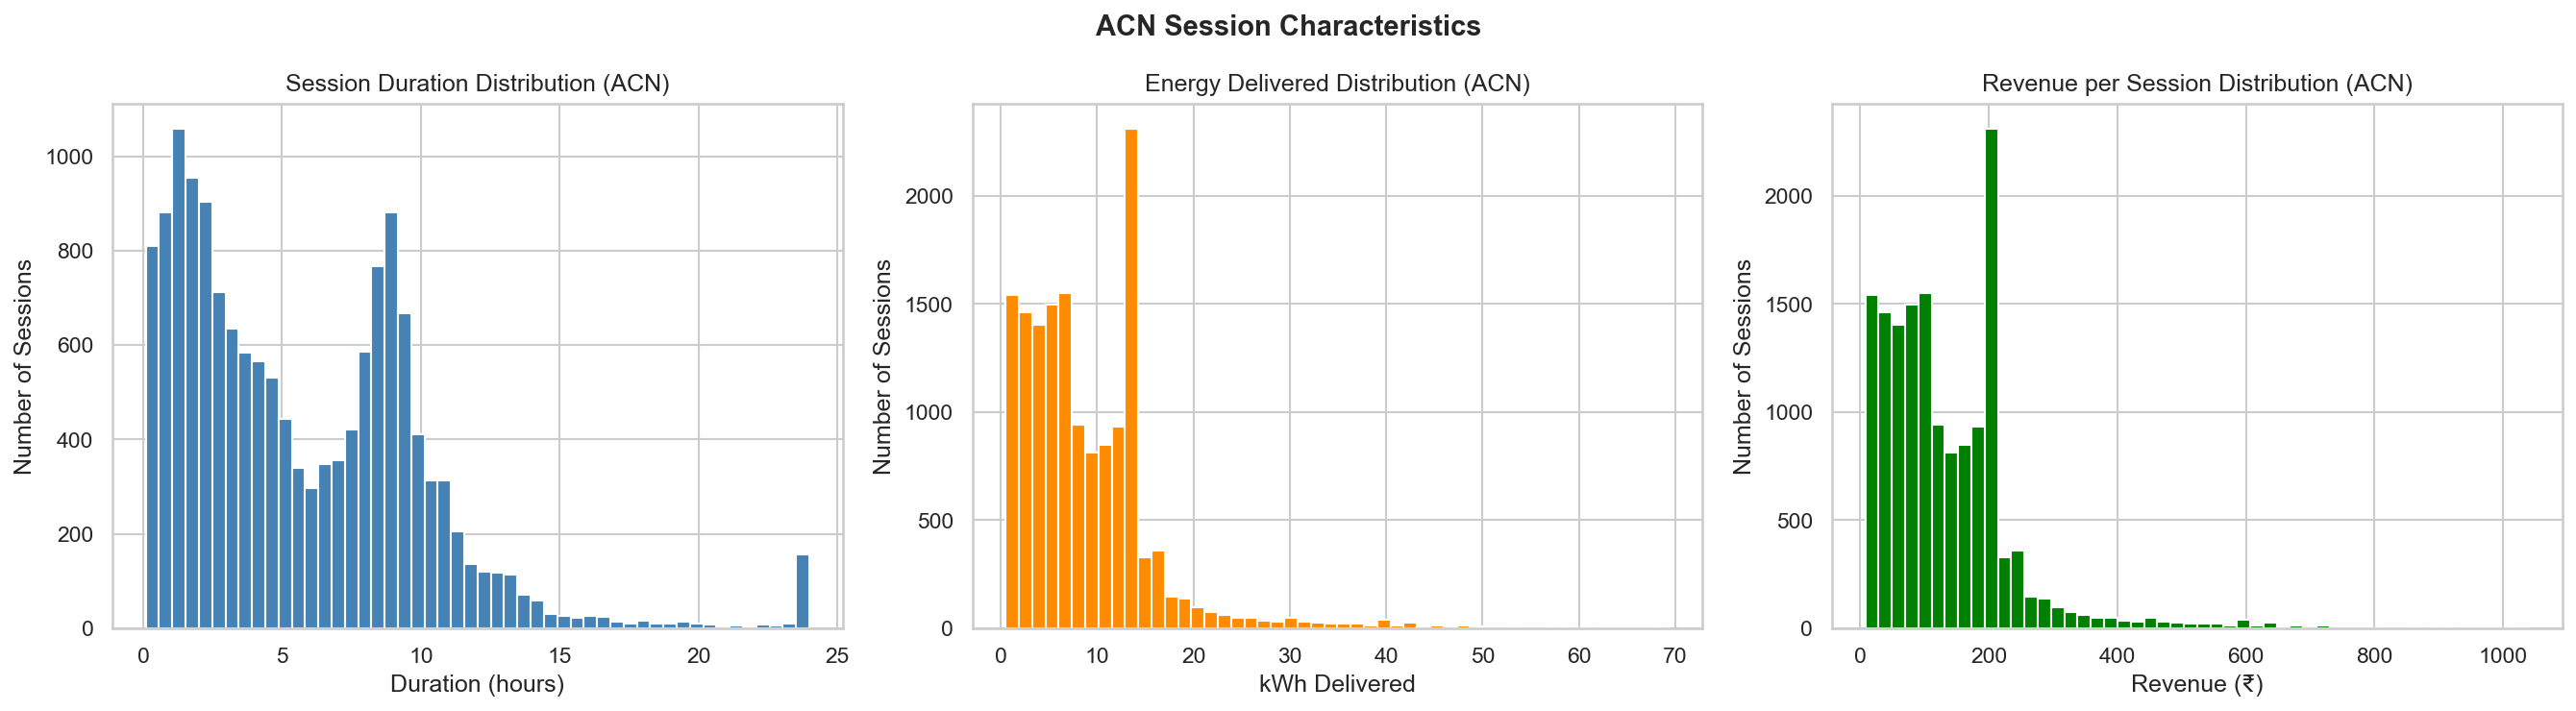

Saved: acn_session_distributions.png


In [7]:
# ACN Data Session Duration and Energy Distribution
# Histograms of session duration, energy delivered, and revenue per session

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Session duration distribution
axes[0].hist(acn['session_duration_hrs'].clip(0, 24), bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('Session Duration Distribution (ACN)')
axes[0].set_xlabel('Duration (hours)')
axes[0].set_ylabel('Number of Sessions')

# kWh delivered distribution
axes[1].hist(acn['kWhDelivered'].clip(0, 80), bins=50,
             color='darkorange', edgecolor='white')
axes[1].set_title('Energy Delivered Distribution (ACN)')
axes[1].set_xlabel('kWh Delivered')
axes[1].set_ylabel('Number of Sessions')

# Revenue distribution
axes[2].hist(acn['revenue_session_inr'].clip(0, 1500), bins=50,
             color='green', edgecolor='white')
axes[2].set_title('Revenue per Session Distribution (ACN)')
axes[2].set_xlabel('Revenue (₹)')
axes[2].set_ylabel('Number of Sessions')

plt.suptitle('ACN Session Characteristics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/eda/acn_session_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: acn_session_distributions.png")

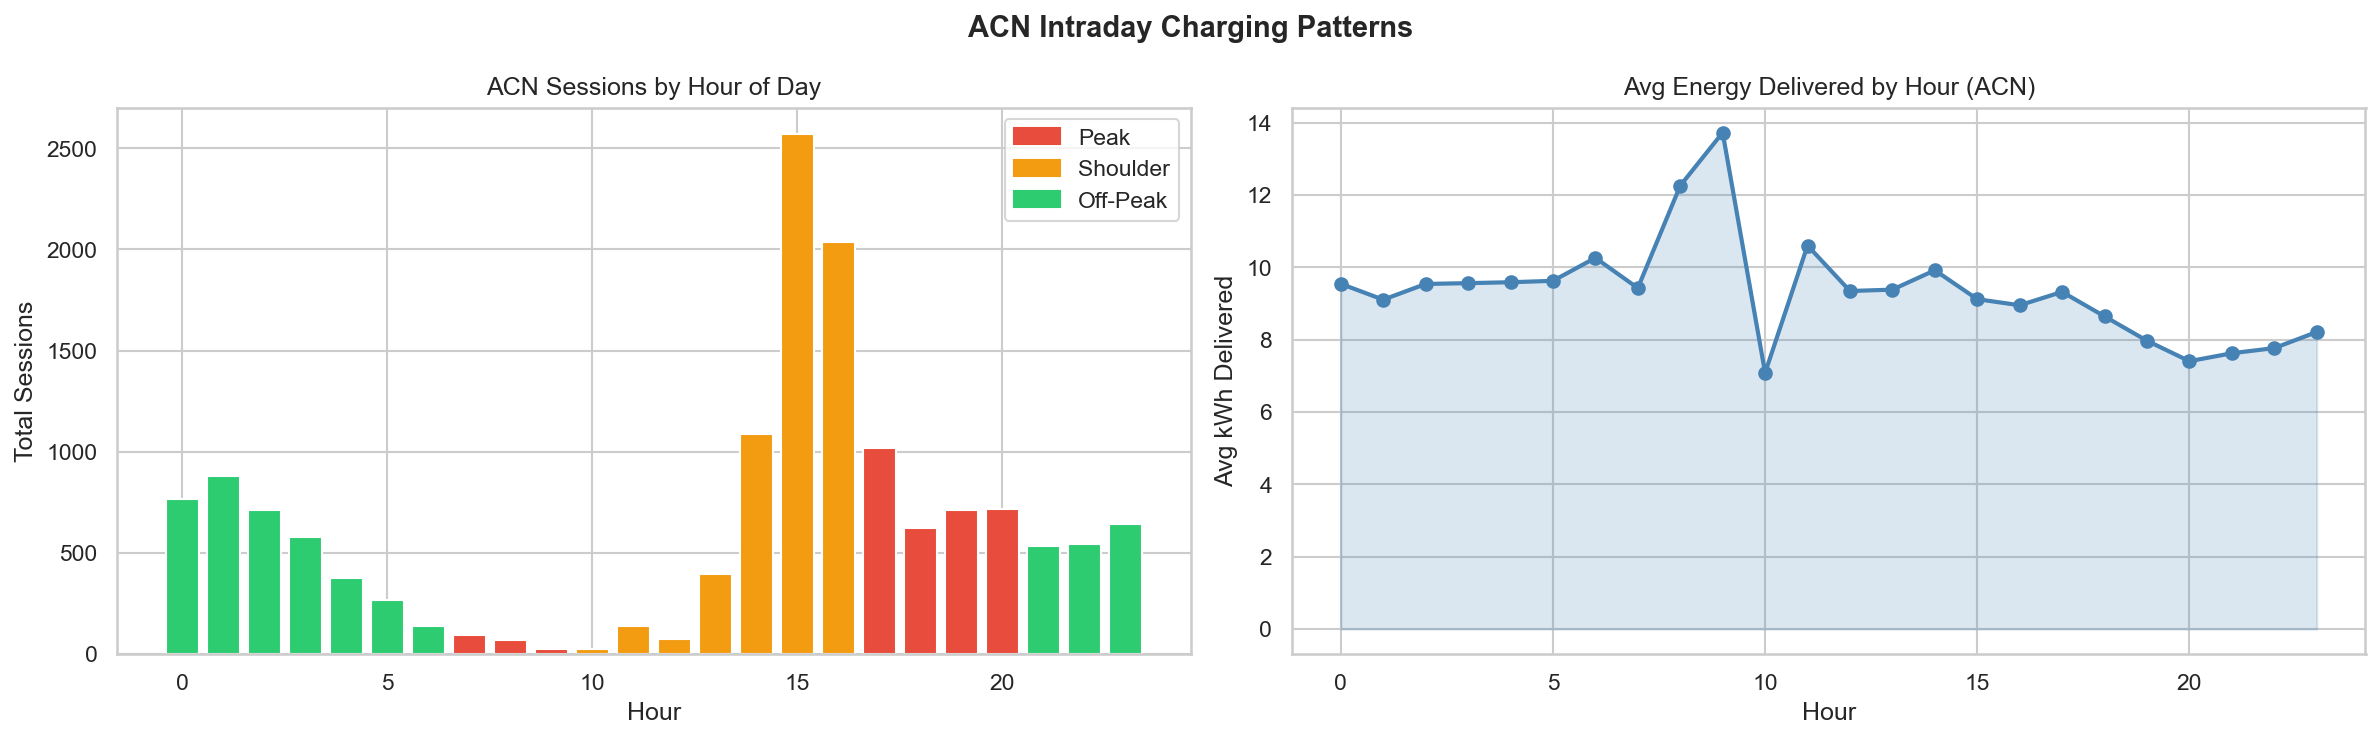

Saved: acn_intraday_pattern.png


In [8]:
# ACN Intraday Pattern
# Sessions and Energy delivered by hour

acn_hourly = acn.groupby(['hour','period']).agg(
    sessions=('kWhDelivered','count'),
    avg_kwh=('kWhDelivered','mean'),
    avg_revenue=('revenue_session_inr','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sessions by hour
bar_colors = acn_hourly.groupby('hour')['period'].first().map({
    'peak':'#e74c3c','shoulder':'#f39c12','off_peak':'#2ecc71'
})
axes[0].bar(acn_hourly.groupby('hour')['sessions'].sum().index,
            acn_hourly.groupby('hour')['sessions'].sum().values,
            color=bar_colors.values, edgecolor='white')
axes[0].set_title('ACN Sessions by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Total Sessions')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#e74c3c', label='Peak'),
    Patch(color='#f39c12', label='Shoulder'),
    Patch(color='#2ecc71', label='Off-Peak')
])

# Avg kWh by hour
acn_kwh = acn.groupby('hour')['kWhDelivered'].mean()
axes[1].plot(acn_kwh.index, acn_kwh.values, marker='o', color='steelblue', linewidth=2)
axes[1].fill_between(acn_kwh.index, acn_kwh.values, alpha=0.2, color='steelblue')
axes[1].set_title('Avg Energy Delivered by Hour (ACN)')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Avg kWh Delivered')

plt.suptitle('ACN Intraday Charging Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/eda/acn_intraday_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: acn_intraday_pattern.png")

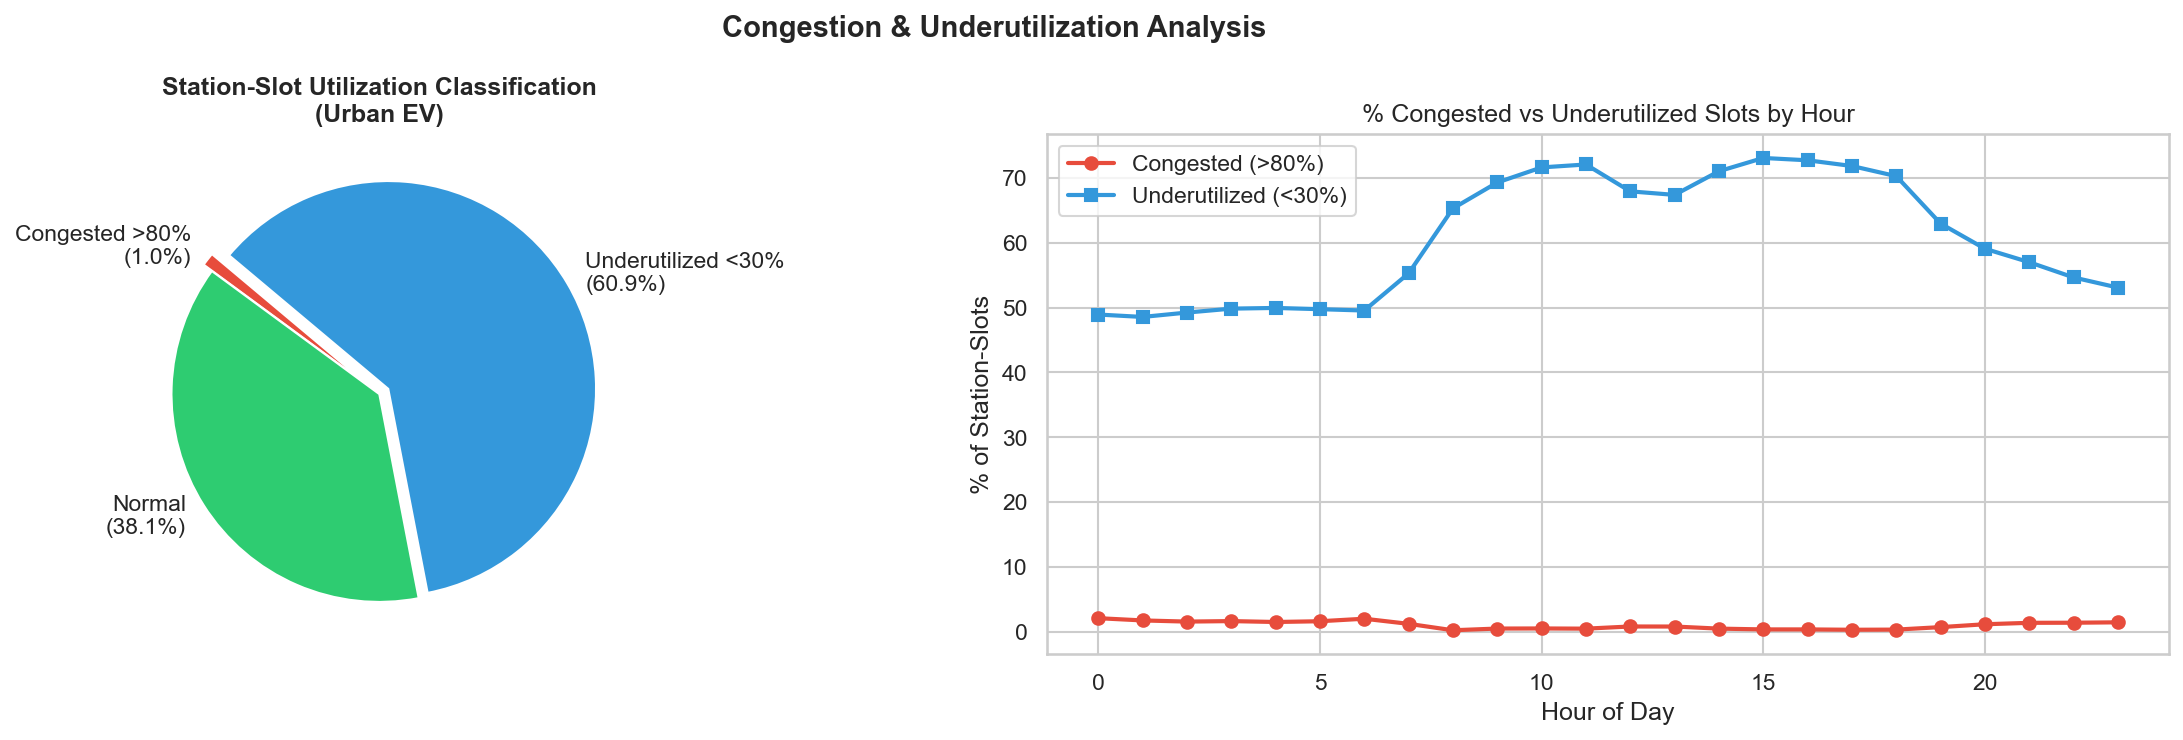

Congested slots:     1.02%
Normal slots:        38.12%
Underutilized slots: 60.85%
Saved: congestion_analysis.png


In [9]:
# Congestion & Underutilization Analysis (Urban EV)
# What % of slots are congested vs underutilized vs normal

congestion_pct = urban['is_congested'].mean() * 100
underutil_pct  = urban['is_underutilized'].mean() * 100
normal_pct     = 100 - congestion_pct - underutil_pct

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pie chart
axes[0].pie(
    [congestion_pct, normal_pct, underutil_pct],
    labels=[f'Congested >80%\n({congestion_pct:.1f}%)',
            f'Normal\n({normal_pct:.1f}%)',
            f'Underutilized <30%\n({underutil_pct:.1f}%)'],
    colors=['#e74c3c','#2ecc71','#3498db'],
    startangle=140,
    explode=[0.05, 0, 0.05]
)
axes[0].set_title('Station-Slot Utilization Classification\n(Urban EV)', fontweight='bold')

# Congestion by hour
cong_hourly = urban.groupby('hour')['is_congested'].mean() * 100
underutil_hourly = urban.groupby('hour')['is_underutilized'].mean() * 100

axes[1].plot(cong_hourly.index, cong_hourly.values,
             marker='o', color='#e74c3c', label='Congested (>80%)', linewidth=2)
axes[1].plot(underutil_hourly.index, underutil_hourly.values,
             marker='s', color='#3498db', label='Underutilized (<30%)', linewidth=2)
axes[1].set_title('% Congested vs Underutilized Slots by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('% of Station-Slots')
axes[1].legend()

plt.suptitle('Congestion & Underutilization Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/eda/congestion_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Congested slots:     {congestion_pct:.2f}%")
print(f"Normal slots:        {normal_pct:.2f}%")
print(f"Underutilized slots: {underutil_pct:.2f}%")
print("Saved: congestion_analysis.png")

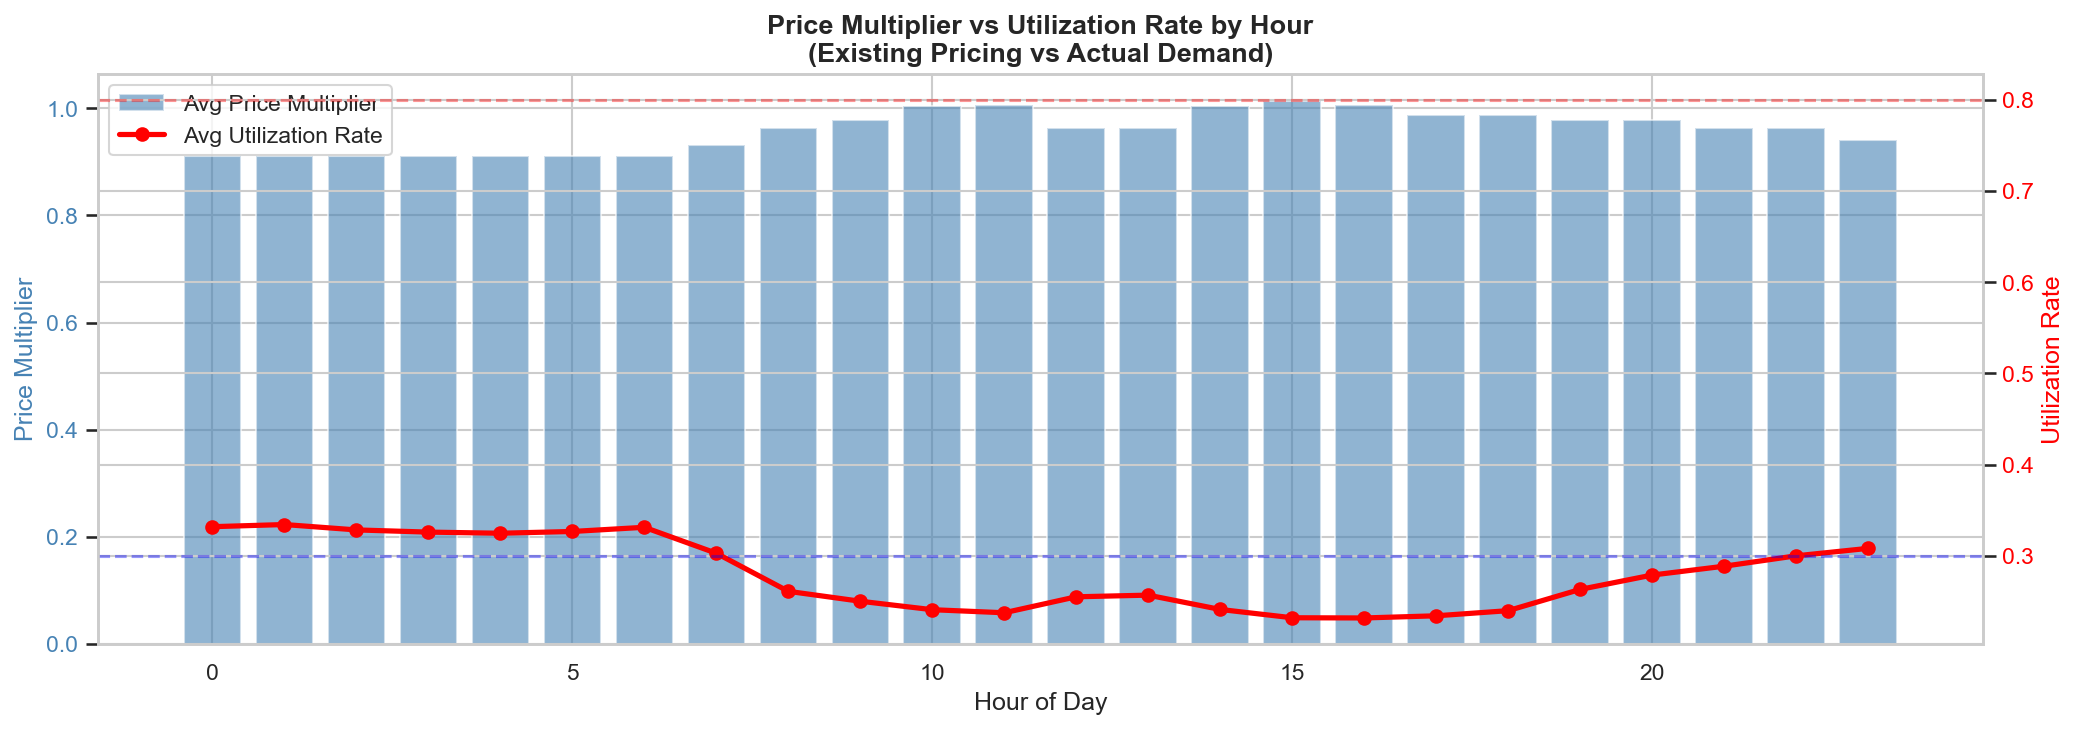

Saved: price_vs_utilization.png


In [10]:
# Price Multiplier Analysis
# How does current price vary by hour and utilization?

price_hourly = urban.groupby('hour')['price_multiplier'].mean()
util_hourly  = urban.groupby('hour')['charger_utilization_rate'].mean()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(price_hourly.index, price_hourly.values,
        color='steelblue', alpha=0.6, label='Avg Price Multiplier')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Price Multiplier', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(util_hourly.index, util_hourly.values,
         color='red', linewidth=2.5, marker='o', label='Avg Utilization Rate')
ax2.set_ylabel('Utilization Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(0.8, color='red', linestyle='--', alpha=0.4)
ax2.axhline(0.3, color='blue', linestyle='--', alpha=0.4)

plt.title('Price Multiplier vs Utilization Rate by Hour\n(Existing Pricing vs Actual Demand)',
          fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../visuals/eda/price_vs_utilization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: price_vs_utilization.png")

In [ ]:
# Export the EDA Summary CSV Files

# 1. Temporal summary
temporal_summary = urban.groupby(['hour','day_of_week','period']).agg(
    avg_occupancy=('occupancy','mean'),
    avg_volume=('volume','mean'),
    avg_utilization=('charger_utilization_rate','mean'),
    avg_revenue_proxy=('revenue_proxy','mean'),
    pct_congested=('is_congested','mean'),
    pct_underutilized=('is_underutilized','mean')
).reset_index().round(4)
temporal_summary.to_csv('../outputs/eda/eda_temporal_summary.csv', index=False)
print("Saved: eda_temporal_summary.csv →", temporal_summary.shape)

# 2. Station summary
station_summary = urban.groupby('station_id').agg(
    avg_utilization=('charger_utilization_rate','mean'),
    avg_occupancy=('occupancy','mean'),
    avg_volume=('volume','mean'),
    avg_revenue=('revenue_proxy','mean'),
    avg_queue=('queue_proxy','mean'),
    pct_congested=('is_congested','mean'),
    pct_underutilized=('is_underutilized','mean'),
    total_chargers=('total_chargers','first'),
    fast_chargers=('fast_chargers','first'),
    latitude=('latitude','first'),
    longitude=('longitude','first')
).reset_index().round(4)
station_summary.to_csv('../outputs/eda/eda_station_summary.csv', index=False)
print("Saved: eda_station_summary.csv →", station_summary.shape)

# 3. Peak vs off-peak volatility summary
period_summary = urban.groupby('period')['charger_utilization_rate'].agg(
    ['mean','std','min','max','median']
).reindex(['peak','shoulder','off_peak']).round(4)
period_summary.to_csv('../outputs/eda/eda_peak_offpeak_summary.csv')
print("Saved: eda_peak_offpeak_summary.csv →", period_summary.shape)

# 4. ACN hourly summary
acn_hourly_summary = acn.groupby(['hour','period']).agg(
    session_count=('kWhDelivered','count'),
    avg_kwh=('kWhDelivered','mean'),
    avg_duration_hrs=('session_duration_hrs','mean'),
    avg_revenue_inr=('revenue_session_inr','mean'),
    avg_utilization=('charger_utilization_rate','mean')
).reset_index().round(4)
acn_hourly_summary.to_csv('../outputs/eda/eda_acn_hourly_summary.csv', index=False)
print("Saved: eda_acn_hourly_summary.csv →", acn_hourly_summary.shape)

print("\nNotebook 2 Complete! All charts and CSVs saved.")

✅ Saved: eda_temporal_summary.csv → (168, 9)
✅ Saved: eda_station_summary.csv → (247, 12)
✅ Saved: eda_peak_offpeak_summary.csv → (3, 5)
✅ Saved: eda_acn_hourly_summary.csv → (24, 7)

✅ Notebook 2 Complete! All charts and CSVs saved.
